# Phase 3 — Collaborative Filtering (scipy SVD, no scikit-surprise)

Collaborative filtering finds patterns in *who* rates things similarly,
not *what* the content is. SVD compresses the sparse user-item matrix
into k latent "taste dimensions" and fills in the blanks.

Matrix shape:  610 users × 9724 movies
Total cells:   5,931,640
Filled cells:  100,836
Density:       1.70%  |  Sparsity: 98.30%


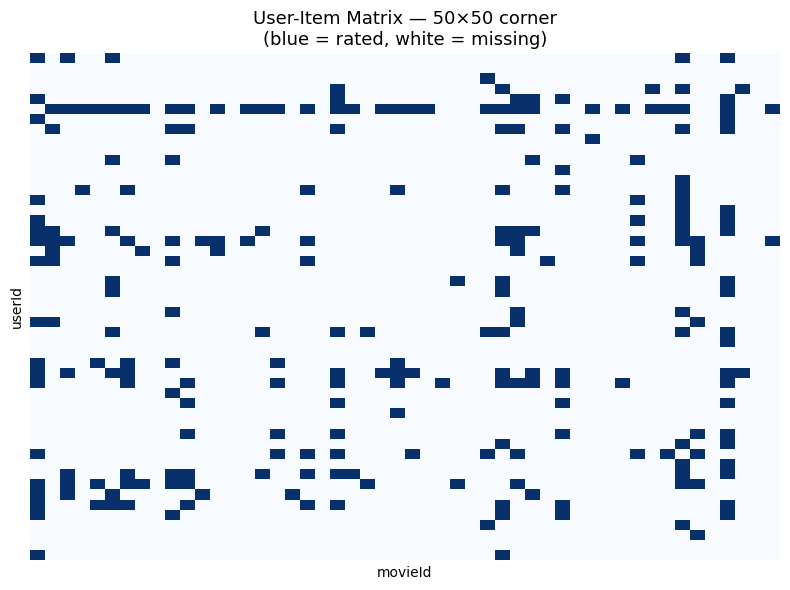

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, root_dir)

ratings = pd.read_csv('../data/raw/ratings.csv')
movies  = pd.read_csv('../data/raw/movies.csv')

from phase3_collaborative_filtering.matrix_factorisation import build_user_item_matrix, compute_sparsity

matrix = build_user_item_matrix(ratings)
compute_sparsity(matrix)

fig, ax = plt.subplots(figsize=(8, 6))
subset = (matrix.iloc[:50, :50] > 0).astype(int)
sns.heatmap(subset, cmap='Blues', cbar=False, ax=ax, linewidths=0, xticklabels=False, yticklabels=False)
ax.set_title('User-Item Matrix — 50×50 corner\n(blue = rated, white = missing)', fontsize=13)
plt.tight_layout()
plt.savefig('../phase3_collaborative_filtering/plots/sparsity_heatmap.png', dpi=150)
plt.show()

In [2]:
from phase3_collaborative_filtering.matrix_factorisation import numpy_svd_decompose

top_users  = ratings['userId'].value_counts().head(100).index
top_movies = ratings['movieId'].value_counts().head(500).index
subset_df  = ratings[ratings['userId'].isin(top_users) & ratings['movieId'].isin(top_movies)]
small_matrix = build_user_item_matrix(subset_df)

U_k, sigma_k, Vt_k, R_hat = numpy_svd_decompose(small_matrix, k=20)

print('Shapes after decomposition:')
print(f'  U_k  (users  × factors): {U_k.shape}')
print(f'  Vt_k (factors × movies): {Vt_k.shape}')
print(f'  R_hat (full reconstructed): {R_hat.shape}')

SVD complete. Kept 20 of 100 factors.
Variance explained: 34.56%
Shapes after decomposition:
  U_k  (users  × factors): (100, 20)
  Vt_k (factors × movies): (20, 500)
  R_hat (full reconstructed): (100, 500)


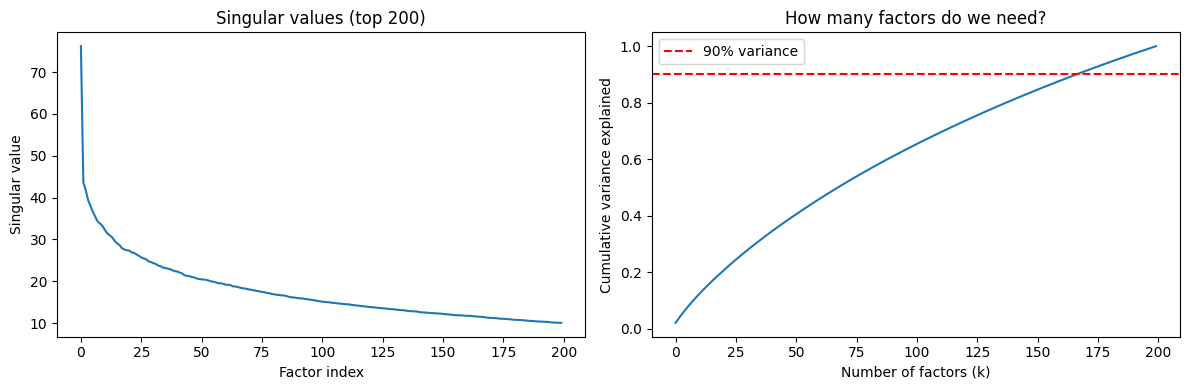

In [3]:
import scipy.sparse as sp
from scipy.sparse.linalg import svds
from phase3_collaborative_filtering.svd_model import build_sparse_matrix, mean_centre_matrix

matrix_sp, user_idx, movie_idx, user_means = build_sparse_matrix(ratings)
matrix_centred = mean_centre_matrix(matrix_sp, user_means)

U200, sigma200, Vt200 = svds(matrix_centred.astype(float), k=200)
sigma200 = sigma200[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sigma200)
axes[0].set_xlabel('Factor index')
axes[0].set_ylabel('Singular value')
axes[0].set_title('Singular values (top 200)')

cumvar = np.cumsum(sigma200) / sigma200.sum()
axes[1].plot(cumvar)
axes[1].axhline(0.9, color='r', linestyle='--', label='90% variance')
axes[1].set_xlabel('Number of factors (k)')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].set_title('How many factors do we need?')
axes[1].legend()

plt.tight_layout()
plt.savefig('../phase3_collaborative_filtering/plots/singular_values.png', dpi=150)
plt.show()

In [4]:
from phase3_collaborative_filtering.svd_model import train_svd, evaluate_model

model = train_svd(ratings, k=100)
metrics = evaluate_model(model, ratings)

Train: 80,668 ratings | Test: 20,168 ratings
Matrix shape: 610 users × 8983 movies
Running truncated SVD with k=100 factors...


SVD complete. Top singular value: 62.08 | k=100



MODEL EVALUATION
Metric               SVD Model        Baseline (mean)
----------------------------------------------------
RMSE                 0.9483           1.0488
MAE                  0.7353           0.8316
RMSE improvement over baseline: 9.6%
Global mean rating: 3.5016


Train: 80,668 ratings | Test: 20,168 ratings
Matrix shape: 610 users × 8983 movies
Running truncated SVD with k=20 factors...
SVD complete. Top singular value: 62.08 | k=20



MODEL EVALUATION
Metric               SVD Model        Baseline (mean)
----------------------------------------------------
RMSE                 0.9303           1.0488
MAE                  0.7177           0.8316
RMSE improvement over baseline: 11.3%
Global mean rating: 3.5016
k=  20  RMSE=0.9303
Train: 80,668 ratings | Test: 20,168 ratings
Matrix shape: 610 users × 8983 movies
Running truncated SVD with k=50 factors...
SVD complete. Top singular value: 62.08 | k=50



MODEL EVALUATION
Metric               SVD Model        Baseline (mean)
----------------------------------------------------
RMSE                 0.9395           1.0488
MAE                  0.7257           0.8316
RMSE improvement over baseline: 10.4%
Global mean rating: 3.5016
k=  50  RMSE=0.9395
Train: 80,668 ratings | Test: 20,168 ratings
Matrix shape: 610 users × 8983 movies
Running truncated SVD with k=100 factors...
SVD complete. Top singular value: 62.08 | k=100



MODEL EVALUATION
Metric               SVD Model        Baseline (mean)
----------------------------------------------------
RMSE                 0.9483           1.0488
MAE                  0.7353           0.8316
RMSE improvement over baseline: 9.6%
Global mean rating: 3.5016
k= 100  RMSE=0.9483
Train: 80,668 ratings | Test: 20,168 ratings
Matrix shape: 610 users × 8983 movies
Running truncated SVD with k=150 factors...


SVD complete. Top singular value: 62.08 | k=150



MODEL EVALUATION
Metric               SVD Model        Baseline (mean)
----------------------------------------------------
RMSE                 0.9524           1.0488
MAE                  0.7393           0.8316
RMSE improvement over baseline: 9.2%
Global mean rating: 3.5016
k= 150  RMSE=0.9524


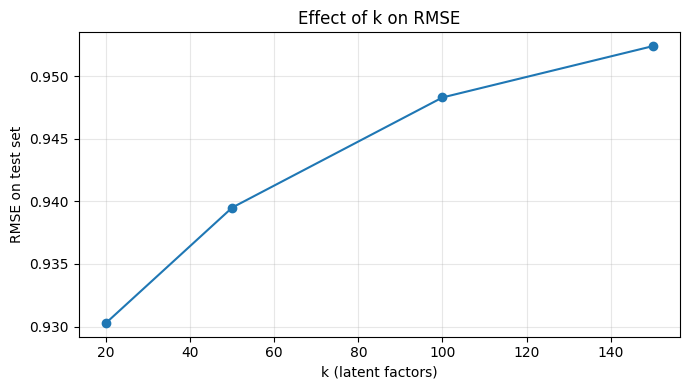

In [5]:
from phase3_collaborative_filtering.svd_model import train_svd, evaluate_model

rmse_by_k = {}
for k in [20, 50, 100, 150]:
    m = train_svd(ratings, k=k)
    result = evaluate_model(m, ratings)
    rmse_by_k[k] = result['rmse']
    print(f'k={k:4d}  RMSE={rmse_by_k[k]:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(list(rmse_by_k.keys()), list(rmse_by_k.values()), marker='o')
plt.xlabel('k (latent factors)')
plt.ylabel('RMSE on test set')
plt.title('Effect of k on RMSE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../phase3_collaborative_filtering/plots/k_vs_rmse.png', dpi=150)
plt.show()

In [6]:
from phase3_collaborative_filtering.svd_model import get_recommendations

for test_user in [1, 42, 200, 500]:
    print(f"\n{'='*50}")
    user_rated = (
        ratings[ratings['userId'] == test_user]
        .merge(movies, on='movieId')
        .sort_values('rating', ascending=False)
        .head(5)
    )
    print(f"User {test_user} — top-rated movies:")
    for _, r in user_rated.iterrows():
        print(f"  {r['rating']}★  {r['title']}")

    recs = get_recommendations(test_user, model, ratings, movies, n=10)
    print(f"\nRecommendations:")
    for _, r in recs.iterrows():
        print(f"  [{r['predicted_rating']:.2f}★]  {r['title']}  ({r['genres']})")


User 1 — top-rated movies:
  5.0★  Seven (a.k.a. Se7en) (1995)
  5.0★  Usual Suspects, The (1995)
  5.0★  Bottle Rocket (1996)
  5.0★  Dumb & Dumber (Dumb and Dumber) (1994)
  5.0★  Billy Madison (1995)

Recommendations:
  [4.73★]  Lord of the Rings: The Return of the King, The (2003)  (Action|Adventure|Drama|Fantasy)
  [4.69★]  Casablanca (1942)  (Drama|Romance)
  [4.69★]  To Kill a Mockingbird (1962)  (Drama)
  [4.64★]  12 Angry Men (1957)  (Drama)
  [4.64★]  Matrix Reloaded, The (2003)  (Action|Adventure|Sci-Fi|Thriller|IMAX)
  [4.62★]  Lady and the Tramp (1955)  (Animation|Children|Comedy|Romance)
  [4.61★]  Trainspotting (1996)  (Comedy|Crime|Drama)
  [4.61★]  Lord of the Rings: The Two Towers, The (2002)  (Adventure|Fantasy)
  [4.61★]  Eternal Sunshine of the Spotless Mind (2004)  (Drama|Romance|Sci-Fi)
  [4.60★]  Bourne Identity, The (2002)  (Action|Mystery|Thriller)

User 42 — top-rated movies:
  5.0★  City Slickers (1991)
  5.0★  Scarface (1983)
  5.0★  Eddie Murphy Raw (1987

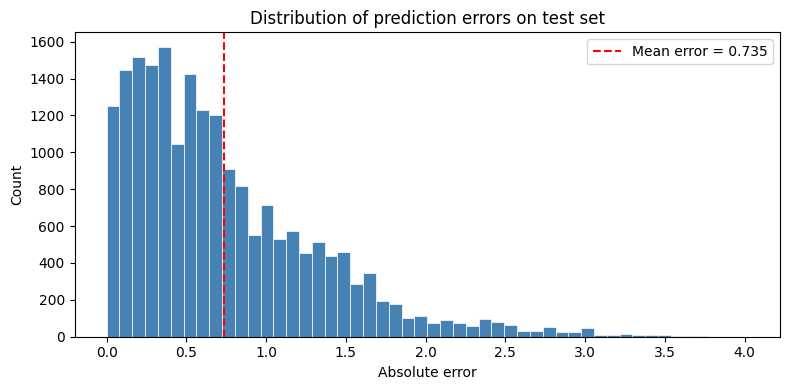

In [7]:
test_df     = model['test_df']
global_mean = ratings['rating'].mean()
errors = []

from phase3_collaborative_filtering.svd_model import predict_rating
for _, row in test_df.iterrows():
    pred = predict_rating(model, int(row['userId']), int(row['movieId']))
    errors.append(abs(row['rating'] - pred))

errors = np.array(errors)

plt.figure(figsize=(8, 4))
plt.hist(errors, bins=50, edgecolor='white', linewidth=0.5, color='steelblue')
plt.axvline(errors.mean(), color='red', linestyle='--', label=f'Mean error = {errors.mean():.3f}')
plt.xlabel('Absolute error')
plt.ylabel('Count')
plt.title('Distribution of prediction errors on test set')
plt.legend()
plt.tight_layout()
plt.savefig('../phase3_collaborative_filtering/plots/error_distribution.png', dpi=150)
plt.show()